In [9]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr

## `Dls_wrt_y_and_R_orbit` definition

In [10]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

In [11]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

## Detector setup

In [12]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

## Detector setup

In [13]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

## Parameters

In [14]:
n_dL = 3
n = 3
shape = (n_dL, n, n)
events = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Sample parameter space
dL_array = np.geomspace(2, 0.2, n_dL) # Gpc
y_array = np.linspace(0.2, 2, n) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n)

dL_mesh, R_orbit_mesh, _ = np.meshgrid(dL_array, R_orbit_array, y_array, indexing='xy')
events['dL'] = dL_mesh
events['R_orbit'] = R_orbit_mesh

# Convert y to src_pos for injection
Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2 * Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S
betas = np.outer(y_array, beta_max / R_orbit_array)
events['src_pos'] = np.repeat(np.expand_dims(betas, axis=0), n, axis=0)

In [20]:
CV_R_threshold = 0.5
SNR_needed = onp.zeros((n, n))
for i in range(n):
    for j in range(n):
        for k in range(n_dL):
            event = {key: val[k, i, j] for key, val in events.items()}

            fisher = HLV_AGN.FisherMatr(event, res=1000)
            # keys = list(event.keys()).copy()
            # reduced_fisher, _ = reduce_Fisher_matrix(fisher, keys=keys)
            # reduced_cov, ie = CovMatr(reduced_fisher)
            cov, ie = CovMatr(fisher)
            cov = onp.asarray(cov)

            idx_R = 7
            std_R = onp.sqrt(cov[idx_R, idx_R])
            CV_R = std_R / onp.array(event['R_orbit'])
            if CV_R <= CV_R_threshold:
                SNR = HLV_AGN.SNR(event, res=1000)
                SNR_needed[i, j] = SNR
                break
SNR_needed

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.874632744764892, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.874632744764892, Maximum duration: 24.60698144251176.

Computing Fisher for L1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.874632744764892, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.874632744764892, Maximum duration: 24.60698144251176.

Computing Fisher for V1...
Warning! Some of the input parameters will 

array([[ 25.54658993,   0.        ,   0.        ],
       [ 45.95965788,  89.74873851, 108.61137619],
       [144.19325261, 213.41890258, 249.40567295]])

Text(0.5, 1.0, '$\\rho$ required for ${\\rm CV}_R\\,\\equiv\\,\\sigma_R\\,/\\,R\\,\\leq\\,0.5$')

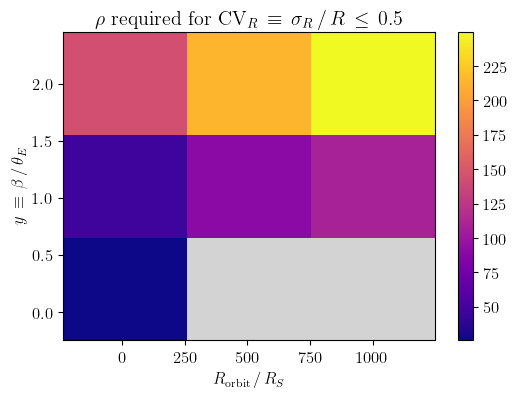

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

SNR_masked = onp.ma.masked_where(SNR_needed == 0, SNR_needed)
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_array, SNR_masked, cmap=cmap,
                #    norm=LogNorm()
                   )
cbar = fig.colorbar(im, ax=ax)
# cbar.set_label(r'${\rm SNR}$', labelpad=10)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')